# Quantum Kernel Methods with QESEM

This notebook focuses on implementing QESEM mitigation methods for evaluating quantum kernels, a fundamental similarity
measure of data that sits at the heart of quantum machine learning. Kernel methods are a key tool for enabling efficient nonlinear learning, where the nonlinearity is absorbed into the kernel itself, keeping the classifier both linear and tractable. We begin by reviewing classical kernels and kernel-based classifiers, and then we will see how variational quantum circuits provides a natural generalization of this concept to the quantum world.

### Introduction to Classical and Quantum Kernel Methods



#### Classical Kernels

Given a dataset of $N$ datapoints $\{x^{(i)}\}$, the classical kernel approach is based on mapping each data point $x^{(i)}\in \mathcal{R}^d$, where $i=1,2,\cdots N$, into a higher-dimensional feature space via a mapping: $\phi(\cdot): R^d\rightarrow R^q$, with $q>d$, where different classes become easier to separate by a simple hyperplane:
<div style="text-align: center;">
  <img src="kernel.png" width="400"/>
</div>
Computing $\phi(x^{(i)})$ explicitly, however, can easily become prohibitively expensive as $q$ grows. This is where the "kernel trick" comes in. The kernel trick circumvents this by working directly with the kernel matrix $K\in \mathcal{R}^{N\times N}$, a symmetric matrix whose entries are the inner product in the feature space:
$$K_{ij}=K_{ji}=\langle \phi(x^{(i)}), \phi(x^{(j)})\rangle.$$
 The key insight here, is that the computation of the elements of $K$, can be done efficiently via a kernel function $\kappa(x^{(i)}, x^{(j)})$ without the need to construct $\phi(x^{(i)})$. A well-known example is the Gaussian kernel (RBF): $\kappa(x^{(i)},x^{(j)})=e^{-\frac{\|x^{(i)}-x^{(j)}\|^2}{2\sigma^2}}$, which corresponds to a map into an infinite-dimensional space, yet can be evaluated in $O(d)$ time. Other common choices include linear, polynomial, and sigmoid kernels.

#### Kernel-Based Classification

Once the kernel matrix is computed, it can be used by classical classifiers. A widely used classical classifier is Support Vector Classifier (SVC). The SVC solves a binary classification problem, by finding the optimal hyperplane that seperates two classes of datapoints with the maximum margin. The margin here is the largest possible distance to the nearest datapoints on either side of the hyperplane (also called support vectors). Crucially, the optimization problem depends only on the kernel and never requires access to the explicit feature map. For a detailed explanation, see the [scikit-learn SVM documentation](https://scikit-learn.org/stable/modules/svm.html).

#### Quantum Kernels
Quantum kernels are a natural analogue of classical kernels, where instead of mapping data into a high-dimensional vector space, we embed it into the quantum Hilbert space. This embedding, $\phi(\cdot)$, can be realized by a variational quantum circuit $U_{\phi}$, whose parameters are set by the data points' features, encoding a classical data point $x^{(i)}$ by a quantum state:
$$|\phi(x^{(i)})\rangle = U_{\phi}(x^{(i)})|0\cdots 0\rangle.$$

One can utilize quantum measurements to extract information from the feature space to construct the kernels. One natural choice is the fidelity kernel, which measures the overlap or the fidelity between two quantum states corresponding to two data points
$$K_{ij} = | (\langle \phi(x^{(i)})|\phi(x^{(j)})\rangle |^2$$
The resulting kerenel is then can be passed to a classical classifier, such as an SVC which uses it to learn a decision boundary and classify new data points.



<hr style="border: 0.7px solid #bbb; margin: 10px 0;">
<hr style="border: 0.7px solid #bbb; margin: 10px 0;">

### Setup

If you are using Google Colab, you can install the dependencies with the following cell:

In [ ]:
%pip install -U pip
%pip install -U "qiskit>=2" qiskit-ibm-catalog numpy scikit-learn matplotlib ipykernel pylatexenc

### Imports

In [2]:
import itertools
import qiskit
import qiskit.circuit
import qiskit.quantum_info
from qiskit.quantum_info import SparseObservable
from qiskit_ibm_catalog import QiskitFunctionsCatalog
from qiskit.primitives.containers.observables_array import ObservablesArray
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

<hr style="border: 0.7px solid #bbb; margin: 10px 0;">
<hr style="border: 0.7px solid #bbb; margin: 10px 0;">

### Binary MNIST Dataset: Loading and Preprocessing

For this tutorial, we will work with a simplified subset of the well-known MNIST dataset, focusing on the two classes of 0 and 1. We will begin with first loading the dataset from `sklearn.datasets`. Each digit is represented as $8\times8$ pixel image, flattened into a $64$-dimensional feature vector.

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

# Keep only the subset corresponding to 0 and 1 digits
mask = (y == 0)|(y == 1)
X_01 = X[mask]
y_01 = y[mask]

print(f"Total # of data points: {len(X_01)}")
print(f"Class 0: {(y_01==0).sum()}")
print(f"Class 1: {(y_01==1).sum()}")

Total # of data points: 360
Class 0: 178
Class 1: 182


Let's visualize the data points corresponding to 0/1 digits images:

--------------------------------------------------------------------------------
The corresponding class for top image (label) is: 1
The corresponding class for bottom image(label) is: 0
--------------------------------------------------------------------------------


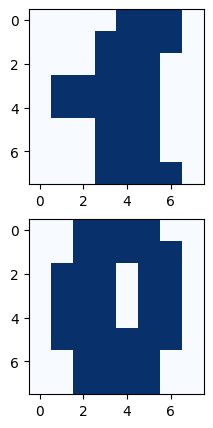

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(5, 5))
im0 = axes[0].imshow(X_01[3].reshape(8,8), cmap="Blues", vmin=0, vmax=1)
im0 = axes[1].imshow(X_01[2].reshape(8,8), cmap="Blues", vmin=0, vmax=1)

print(40*"--")
print(f"The corresponding class for top image (label) is: {y_01[3]}")
print(f"The corresponding class for bottom image(label) is: {y_01[2]}")
print(40*"--")

Now let's split the data into training and testing datasets:

In [644]:
n_train = 40   # 20 per class 0/1
n_test  = 20   #  10 per class 0/1

rng   = np.random.default_rng(42)

sel_0 = rng.choice(np.where(y_01 == 0)[0], int(n_test/2 + n_train/2), replace=False)
sel_1 = rng.choice(np.where(y_01 == 1)[0], int(n_test/2 + n_train/2), replace=False)

X_subset = np.vstack([X_01[sel_0], X_01[sel_1]])
y_subset = np.array([0] * int(n_test/2 + n_train/2) +
                    [1] * int(n_test/2 + n_train/2))

# Now shuffle all the datasets
idx = rng.permutation(len(y_subset))
X_subset = X_subset[idx]
y_subset = y_subset[idx]

# split to train/test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset,
    test_size=n_test,
    random_state=42,
    stratify=y_subset
)

print(f"\nTrain: {X_train.shape}  classes: {np.bincount(y_train)}")
print(f"Test:  {X_test.shape}   classes: {np.bincount(y_test)}")


Train: (40, 64)  classes: [20 20]
Test:  (20, 64)   classes: [10 10]

Train, after PCA: (40, 4)
Test, after PCA:  (20, 4)
Train features range: [0.00, 6.28]
Test  features range: [0.00, 6.07]


To keep things even simple, let us reduce the number of features from $64$ to $4$ using *PCA*, and also apply `MinMaxScaler` transformation to make sure the final values fall in the range $[0, 2\pi]$:

In [ ]:
# PCA
n_qubits = 4
pca = PCA(n_components=n_qubits, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)
print(f"\nTrain, after PCA: {X_train_pca.shape}")
print(f"Test, after PCA:  {X_test_pca.shape}")

mms = MinMaxScaler(feature_range=(0, 2*np.pi))
x_train = mms.fit_transform(X_train_pca)   # fit on train only
x_test  = mms.transform(X_test_pca)         # apply to test
# we can clip the x_test if we wish..
x_test = np.clip(x_test, 0, 2*np.pi)

print(f"Train features range: [{x_train.min():.2f}, "
      f"{x_train.max():.2f}]")
print(f"Test  features range: [{x_test.min():.2f}, "
      f"{x_test.max():.2f}]")

<hr style="border: 0.7px solid #bbb; margin: 10px 0;">
<hr style="border: 0.7px solid #bbb; margin: 10px 0;">

#### Feature Maps
We consider here two different types of quantum feature maps:
1) **ZZ feature map**: similar to the Qiskit `ZZFeatureMap`, see docs [here](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.ZZFeatureMap), but is based on RZZ gates instead CP's. The circuit is composed of repeated layers, each consisting of:

    - A layer of hadamard gates on all qubits
    - A layer of Rz gates with rotation angles given by the feature values $x^{(i)}_j$'s applied qubit-wise in $j$.
    - A "linear entanglement" layers of RZZ gates acting on all neighboring pairs of qubits $(j,k)$, with rotation angles $(\pi-x^{(i)}_j)\cdot(\pi-x^{(i)}_k)$.

In [664]:
def zz_feature_map(num_qubits, labels=None, reps=2):
    """
    The encoding (parameterized) circuit of the ZZ feature map, with linear entanglement.

    """
    if labels is None:
        labels = np.arange(num_qubits)
    x = [qiskit.circuit.Parameter(f"param{i}") for i in labels]
    bonds = [[(q, q+1) for q in range(s, num_qubits-1, 2)] for s in range(2)]

    circ = qiskit.QuantumCircuit(num_qubits)

    for rep in range(reps):
        for q in range(num_qubits):
            circ.h(q)
            circ.rz(x[q], q)

        for l in bonds:
            for b in l:
                circ.rzz(
                    (np.pi - x[b[0]]) * (np.pi - x[b[1]]),
                    b[0], b[1],
                )

    return circ


2) Ising trotter feature map with a Haar random initial state: This is a Trotter-Ising variation of embedding E3, Appendix L.1 in https://arxiv.org/pdf/2011.01938).

    - Apply a random unitary on every qubit (this unitary is determined by the seed parameter)
    - Repeat reps times:

        2.1 For every qubit q, apply $R_X^{(q)}(hx_q)$

        2.2 For every neighbor qubits (q1,q2) apply $R_{ZZ}^{(q_1,q_2)}(J \cdot x_{q_1} \cdot x_{q_2})$

In [648]:
def ising_trotter_feature_map(feature_dimension, reps, h, J, labels=None, seed=42):
    """
    Constructs a quantum circuit for the Ising Trotter feature map.
    Parameters:
        feature_dimension (int): Number of qubits.
        reps (int): Number of steps.
        h (float): Coefficient of Rx.
        J (float): Coefficient of Rzz.
        seed (int, optional): Seed for random number generator. Defaults to 99595.
    Returns:
        QuantumCircuit: The constructed quantum circuit.
    Example:
        ising_trotter_feature_map(4, 2, 0.5, 0.1, seed=12345)
    """
    # p = ParameterVector(parameters_label, feature_dimension)
    if labels is None:
        labels = np.arange(feature_dimension)
    p = [qiskit.circuit.Parameter(f"param{i}") for i in labels]
    qc = qiskit.QuantumCircuit(feature_dimension)

    # start with a haar random state
    rng = np.random.default_rng(seed)
    for q in range(feature_dimension):
        qc.rz(rng.uniform() * 2 * np.pi, q)
        qc.rx(rng.uniform() * 2 * np.pi, q)
        qc.rz(rng.uniform() * 2 * np.pi, q)

    qc.barrier()

    # `reps` repetitions
    for r in range(reps):
        for q in range(feature_dimension):
            qc.rx(h * p[q], q)
        qc.barrier()
        for q in range(0, feature_dimension - 1, 2):
            qc.rzz(J * p[q] * p[q + 1], q, q + 1)
        for q in range(1, feature_dimension - 1, 2):
            qc.rzz(J * p[q] * p[q + 1], q, q + 1)
        qc.barrier()
    return qc

<hr style="border: 0.7px solid #bbb; margin: 10px 0;">
<hr style="border: 0.7px solid #bbb; margin: 10px 0;">

#### Quantum Kernels

For the quantum kernels, we consider two types: the **Fidelity kernel** and the **Projected kernel**. The Fidelity kernel was introduced above. A well-known issue of fidelity kernels is *concentration of measure*, meaning that for large feature space dimension, the fidelity kernel tends to regard data points to be far from each other and the kernel matrix will be close to identity, rendering it to be informative for learning. The projected kernel ([ref](https://www.nature.com/articles/s41467-021-22539-9.pdf)) addresses this by avoiding computation of similarity in the exponentially large Hilbert space.  Instead, one prepares the quantum state embedding each data point, computes low-dimensional projectors onto those states, and evaluates the kernel on the resulting measurement outcomes. Concretely, the projectors are taken to be the single-qubit reduced density matrices (1-RDM's) of the quantum states, $\rho_k(x)$ that are determined by the measurements of $\langle X_k\rangle$'s, $\langle Y_k\rangle$'s, and $\langle Z_k\rangle$'s on each qubit $k$. Then, the kernel is computed via:
$$k^{\mathrm{PQ}}(x_i, x_j) = \exp\left(-\gamma \sum_{k} \|\rho_k(x_i) - \rho_k(x_j)\|_F^2\right)$$

For two single-qubit density matrices $\rho$ and $\sigma$, the squared Frobenius distance is given as:

$||\rho - \sigma||_F^2=\frac{1}{2} tr((\rho-\sigma)^2) = ((\langle X \rangle_\rho- \langle X \rangle_\sigma)^2  + (\langle Y \rangle_\rho- \langle Y \rangle_\sigma)^2  + (\langle Z \rangle_\rho- \langle Z \rangle_\sigma)^2  )$

<hr style="border: 0.7px solid #bbb; margin: 10px 0;">

### Classical Simulation of Quantum Kernel Training and Evaluation

The functions below compute the ideal kernel via exact classical simulation and visualize the result. Specifically, for training and testing a classical optimizer as SVC, we need two kernels:

1. Train kernel $K_{train} \in R^{N_{train}\times N_{train}}$, which is the kernel matrix evaluated on all pairs of training points. This is used by the SVC to learn the optimal decision boundary.
2. The test kernel, $K_{test} \in R^{N_{test}\times N_{train}}$, which is the kernel matrix evaluated between all test points and all training points. This is used at inference time to evaluate learning accuracy, and diagnose overfitting.

Both matrices are required because the SVC decision function takes the form $f(x)=\sum_i \alpha_i y_i k(x, x_i)+b$, where here the sum runs over training points, $y_i$'s are the corresponding class labels and $\alpha_i$'s are the learned coefficients determined by the optimization of the SVC objective.

In [651]:
def fidelity_circ(feature_map_circ_1, feature_map_circ_2):
    """
    Obtains the feature map corresponding to the first data point and feature map circuit corresponding to the second data point, and returns the fidelity (ComputeUncompute) circuit.
    """
    qc = feature_map_circ_1.copy()
    qc.compose(feature_map_circ_2.inverse(), inplace=True)
    return qc

def generate_single_qubit_paulis(num_qubits):
    pauli_list = [
        qiskit.quantum_info.SparsePauliOp.from_sparse_list([([o], [q], 1)], num_qubits=num_qubits)
        for o, q in itertools.product(["X", "Y", "Z"], range(num_qubits))
    ]
    return pauli_list

def compute_pauli_expectations(parameterized_circ: qiskit.QuantumCircuit, X: np.array):
    """
    Computes the singel qubit Pauli expectation values for a given parameterized quantum circuit and a set of parameter input values.
    Parameters:
        parameterized_circ (qiskit.QuantumCircuit): The parameterized quantum circuit.
        X (np.array): The set of parameters (dataset) of shape = (num datapoints, num features).
    Returns:
        A list of dictionaries, where each dictionary contains the Pauli expectations for a specific datapoint.
        The keys of the dictionaries are the Pauli operators and the values are the corresponding expectation values.
    """
    one_qubits_paulis = generate_single_qubit_paulis(parameterized_circ.num_qubits)
    pauli_evals_per_x = []
    for n, x in enumerate(X):
        # compute output state or density matrix:
        U_assigned = parameterized_circ.assign_parameters(x)
        state = Statevector(U_assigned)
        pauli_evals_per_x.append({p.paulis[0]: state.expectation_value(p).real for p in one_qubits_paulis})
    return pauli_evals_per_x


def compute_frob_dists_from_expectation_values(pauli_evals_per_x):
    frob_dists_squared = np.zeros((len(pauli_evals_per_x), len(pauli_evals_per_x)))
    for i in range(len(pauli_evals_per_x)):
        for j in range(i+1, len(pauli_evals_per_x)):
            frob_dists_squared[i, j] =  sum((val_i - pauli_evals_per_x[j][p])**2 for p,val_i in pauli_evals_per_x[i].items())
            frob_dists_squared[j, i] = frob_dists_squared[i, j]
    return frob_dists_squared


def compute_ideal_kernel(x_train , x_test, feature_map_circ, params=None, method="fidelity_kernel"):
    """
    train_data: train_data set.
    test_data: test_data set.
    feature_map_circ: the parametrized feaure map circuit.
    method: The method to compute the kernel matrix. The options include "fidelity_kernel", "projected_kernel".
    """
    if method == "fidelity_kernel":
        K_train_ideal = np.zeros((x_train.shape[0], x_train.shape[0]))
        K_test_ideal = np.zeros((x_test.shape[0], x_train.shape[0]))
        K_train_ideal[np.diag_indices_from(K_train_ideal)] = 1
        for i in range(x_train.shape[0]):
            for j in range(i+1, x_train.shape[0]):
                circ = fidelity_circ(feature_map_circ.assign_parameters(x_train[i]), feature_map_circ.assign_parameters(x_train[j]))
                state = qiskit.quantum_info.Statevector(circ)
                K_train_ideal[i, j] = state.probabilities()[0]
                K_train_ideal[j, i] = K_train_ideal[i, j]
        for i in range(x_test.shape[0]):
            for j in range(x_train.shape[0]):
                circ = fidelity_circ(feature_map_circ.assign_parameters(x_test[i]), feature_map_circ.assign_parameters(x_train[j]))
                state = qiskit.quantum_info.Statevector(circ)
                K_test_ideal[i, j] = state.probabilities()[0]

    elif method == "projected_kernel":
        g = params["g"]
        x_full = np.concatenate([x_train,x_test])
        pauli_evals_per_x = compute_pauli_expectations(feature_map_circ, x_full)
        F = compute_frob_dists_from_expectation_values(pauli_evals_per_x)
        K_full = np.exp(-g * F)
        K_train_ideal = K_full[:len(X_train), :len(X_train)]
        K_test_ideal = K_full[len(X_train): , :len(X_train)]
    return K_train_ideal, K_test_ideal


def visulaize_kernel(K_train_ideal, K_test_ideal):

    # TODO delete the diagnostics when done
    print("=== K_train diagnostics ===")
    off_diag = K_train_ideal[~np.eye(K_train_ideal.shape[0], dtype=bool)]
    print(f"Shape:               {K_train_ideal.shape}")
    print(f"Diagonal mean:       {np.diag(K_train_ideal).mean():.4f}")
    print(f"Off-diagonal mean:   {off_diag.mean():.4f}")
    print(f"Off-diagonal std:    {off_diag.std():.4f}")
    print(f"Off-diagonal min:    {off_diag.min():.4f}")
    print(f"Off-diagonal max:    {off_diag.max():.4f}")

    # ── Visualize ──
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(K_train_ideal, cmap="Blues", vmin=0, vmax=1)
    axes[0].set_title("K_train")
    axes[0].set_xlabel("training point j")
    axes[0].set_ylabel("training point i")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(K_test_ideal, cmap="Reds", vmin=0, vmax=1)
    axes[1].set_title("K_test")
    axes[1].set_xlabel("training point j")
    axes[1].set_ylabel("test point i")
    plt.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.show()

<hr style="border: 0.7px solid #bbb; margin: 10px 0;">


#### Examples

#### 1. Kernel method: Fidelity Kernel, Feature Map: ising trotter with random initial state feature_map, dataset: Binary MNIST

=== K_train diagnostics ===
Shape:               (40, 40)
Diagonal mean:       1.0000
Off-diagonal mean:   0.3217
Off-diagonal std:    0.2253
Off-diagonal min:    0.0013
Off-diagonal max:    0.9667


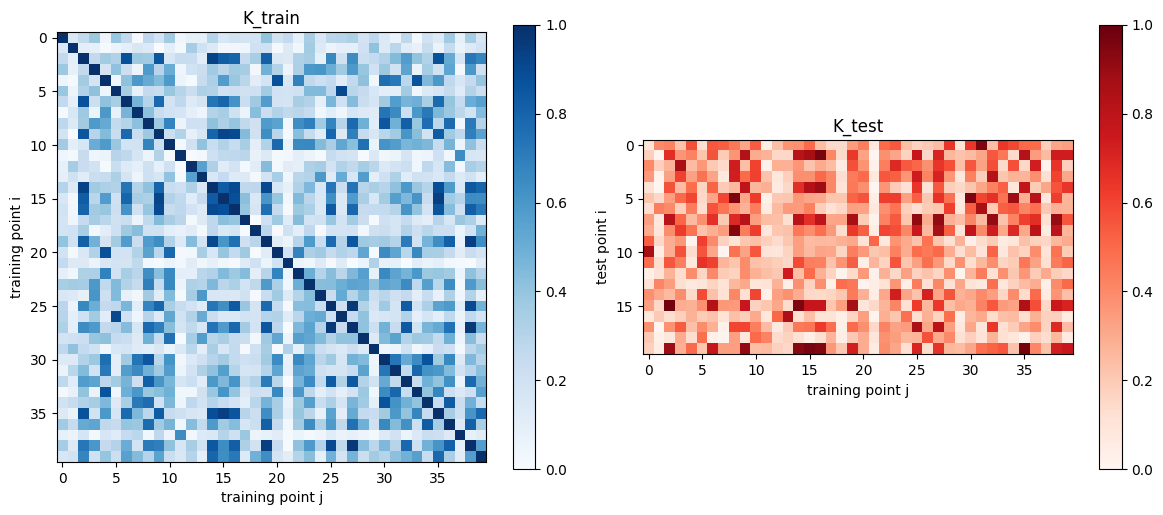

In [652]:
h = 0.15
J = 0.25
params = {"g":0.35}

# Example 1: ising_trotter_feature_map and using the "fidelity kernel".
K_train_ideal_ising_fidelity, K_test_ideal_ising_fidelity = compute_ideal_kernel(x_train , x_test, ising_trotter_feature_map(n_qubits, 2, h, J), params=params, method="fidelity_kernel")
visulaize_kernel(K_train_ideal_ising_fidelity, K_test_ideal_ising_fidelity)




#### 2. Kernel method: Projected Kernel, Feature Map: ising trotter with random initial state feature_map, dataset: Binary MNIST

=== K_train diagnostics ===
Shape:               (40, 40)
Diagonal mean:       1.0000
Off-diagonal mean:   0.4784
Off-diagonal std:    0.1870
Off-diagonal min:    0.0998
Off-diagonal max:    0.9766


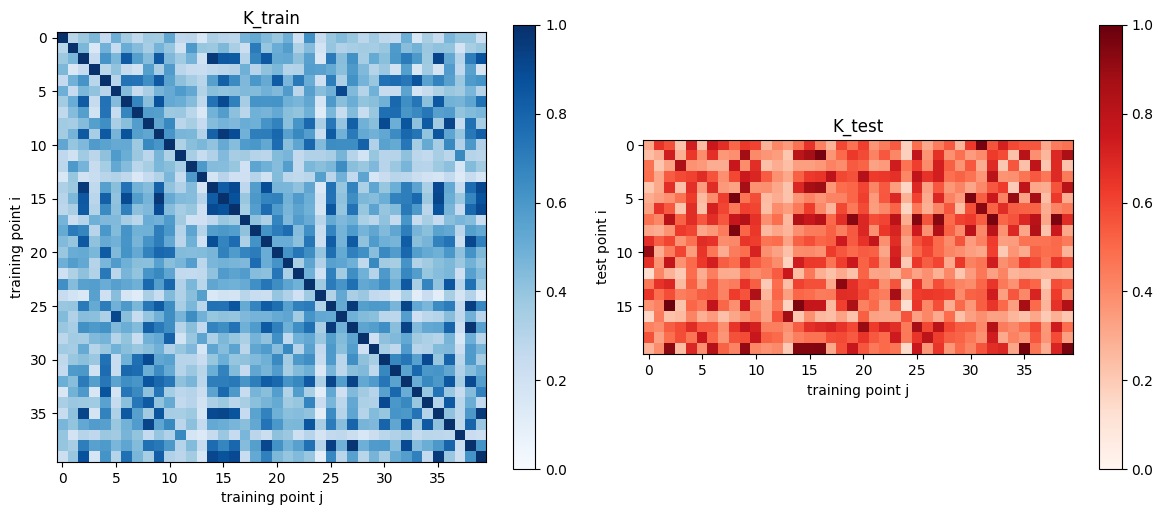

In [653]:
# Example 2: ising_trotter_feature_map and using the "projected kernel".
K_train_ideal_ising_projected, K_test_ideal_ising_projected = compute_ideal_kernel(x_train , x_test, ising_trotter_feature_map(n_qubits, 2, h, J), params=params, method="projected_kernel")

visulaize_kernel(K_train_ideal_ising_projected, K_test_ideal_ising_projected)


#### 3. Kernel method: Fidelity Kernel, Feature Map: ZZ feature map, dataset: Binary MNIST

=== K_train diagnostics ===
Shape:               (40, 40)
Diagonal mean:       1.0000
Off-diagonal mean:   0.1102
Off-diagonal std:    0.1419
Off-diagonal min:    0.0000
Off-diagonal max:    0.8284


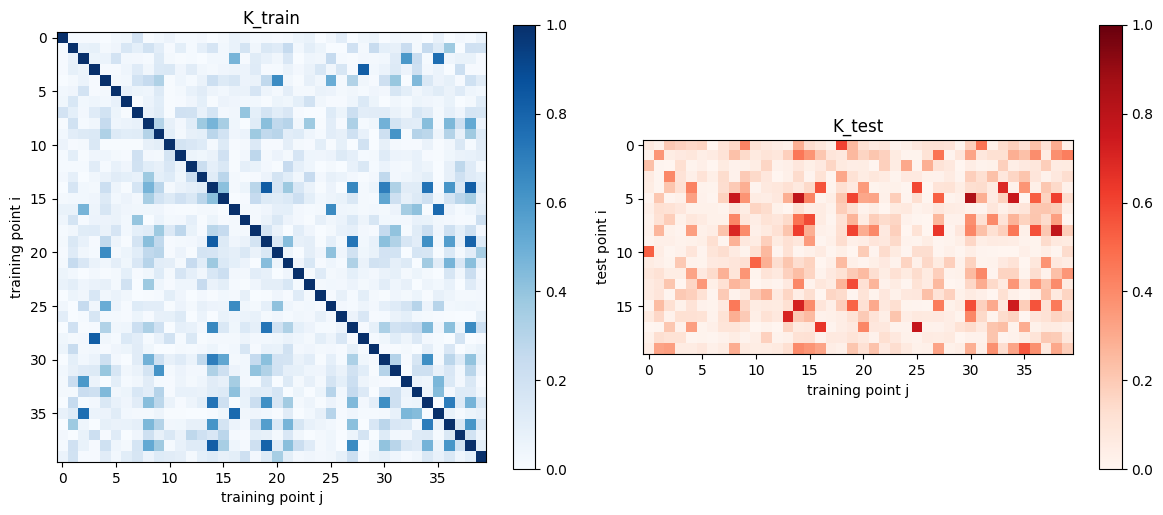

In [665]:
# Example 3: zz_feature_map and using the "fidelity kernel".
K_train_ideal_zz_fidelity, K_test_ideal_zz_fidelity = compute_ideal_kernel(x_train , x_test, zz_feature_map(n_qubits, reps=2), params=params, method="fidelity_kernel")
visulaize_kernel(K_train_ideal_zz_fidelity, K_test_ideal_zz_fidelity)


#### 4. Kernel method: Projected Kernel, Feature Map: ZZ feature map, dataset: Binary MNIST

=== K_train diagnostics ===
Shape:               (40, 40)
Diagonal mean:       1.0000
Off-diagonal mean:   0.3359
Off-diagonal std:    0.1597
Off-diagonal min:    0.0295
Off-diagonal max:    0.9555


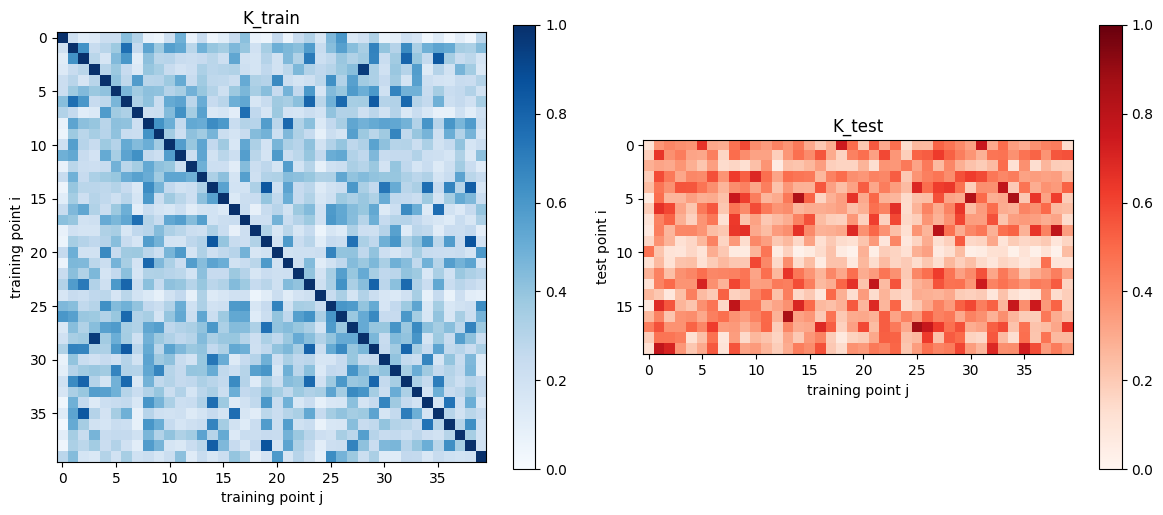

In [668]:

# Example 4: zz_feature_map and using the "projected kernel".
K_train_ideal_zz_projected, K_test_ideal_zz_projected = compute_ideal_kernel(x_train , x_test, zz_feature_map(n_qubits, reps=2), params=params, method="projected_kernel")
visulaize_kernel(K_train_ideal_zz_projected, K_test_ideal_zz_projected)

<hr style="border: 0.7px solid #bbb; margin: 10px 0;">


### Training SVC on the obtained Kernels

In [672]:
# Train SVC classifier using precomputed kernel matrices
# 1st example
svc_ising_fidelity = SVC(kernel="precomputed", C=1)
svc_ising_fidelity.fit(K_train_ideal_ising_fidelity, y_train)
y_pred_ising_fidelity = svc_ising_fidelity.predict(K_test_ideal_ising_fidelity)
accuracy_fidelity = accuracy_score(y_test, y_pred_ising_fidelity)
print(f"Accuracy, example #1, fidelity kernel+Ising with random state feature map: {accuracy_fidelity:.2%}")

# 2nd example
svc_ising_projected = SVC(kernel="precomputed", C=10)
svc_ising_projected.fit(K_train_ideal_ising_projected, y_train)
y_pred_ising_projected = svc_ising_projected.predict(K_test_ideal_ising_projected)
accuracy_projected = accuracy_score(y_test, y_pred_ising_projected)
print(f"Accuracy, example #2, projected kernel+Ising with random state feature map: {accuracy_projected:.2%}")

# Note: the regularization parameter C controls the trade-off between
# margin maximization and training error --> C should be tuned to balance accuracy and generalization.

Accuracy, example #1, fidelity kernel+Ising with random state feature map: 90.00%
Accuracy, example #2, projected kernel+Ising with random state feature map: 90.00%


In [673]:
#3rd example
svc_zz_fidelity = SVC(kernel="precomputed", C=1)
svc_zz_fidelity.fit(K_train_ideal_zz_fidelity, y_train)
# Prediction
y_pred_zz_fidelity = svc_zz_fidelity.predict(K_test_ideal_zz_fidelity)
accuracy_fidelity = accuracy_score(y_test, y_pred_zz_fidelity)
print(f"Accuracy, example #3, fidelity kernel + ZZ feature map: {accuracy_fidelity:.2%}")

# 4th example
svc_zz_projected = SVC(kernel="precomputed", C=1)
svc_zz_projected.fit(K_train_ideal_zz_projected, y_train)
y_pred_zz_projected = svc_zz_projected.predict(K_test_ideal_zz_projected)
accuracy_projected = accuracy_score(y_test, y_pred_zz_projected)
print(f"Accuracy, example #4, projected kernel + ZZ feature map: {accuracy_fidelity:.2%}")





Accuracy, example #3, fidelity kernel + ZZ feature map: 90.00%
Accuracy, example #4, projected kernel + ZZ feature map: 90.00%


<hr style="border: 0.7px solid #bbb; margin: 10px 0;">
<hr style="border: 0.7px solid #bbb; margin: 10px 0;">

## Mitigated Quantum Kernel Estimation via QESEM

Up to this point, we have been working with ideal classical simulations. We now turn to real quantum hardware, where QESEM is used to evaluate the elements of kernel matrices. Here we use fake backends for demonstration, but switching to a real device requires only replacing the backend name: `fake_fez` → `ibm_fez`.

Since this use case relies on parameterized circuits, two approaches are available:
- Submitting each circuit as an individual QESEM job
- Leveraging QESEM's parameterized circuit feature to batch multiple circuit instances, each corresponding to a different set of parameters, into a single job.

We demonstrate here both of the approaches for evaluating some of the kernel matrices considered here.

<hr style="border: 0.7px solid #bbb; margin: 10px 0;">


### Setting up IBM credentials and loading the QESEM function


In [ ]:
# TODO: add your IBM token and instance here
IBM_token = ""
channel = "ibm_quantum_platform"
ibm_instance = ""
catalog = QiskitFunctionsCatalog(channel=channel,
                                 token=IBM_token,
                                 instance=ibm_instance)
qesem_function = catalog.load("qedma/qesem")

<hr style="border: 0.7px solid #bbb; margin: 10px 0;">

### Evaluating the Fidelity Kernel with QESEM


Let's begin by evaluating the element $K_{2,9} = |\langle \phi(x_{2}) | \phi(x_{9}) \rangle|^2$ as a single QESEM job, then show how multiple elements can be evaluated within a single job.

A QESEM job takes the following main inputs, passed as a pub:

1. Circuit - the quantum circuit to be executed (parameterized or not).
2. Observable(s) - one or more observables to measure.
3. Parameter values (optional) - required if the circuit is parameterized.
4. Precision - the target accuracy for the mitigated expectation values in absolute value.

in addition, it takes the backend name as well as additional options as we'll see in the examples below.

In [704]:
# Defining the circuit
i,j = 2, 9
circ_2_9_fid = fidelity_circ(ising_trotter_feature_map(n_qubits, 2, h, J, labels=range(n_qubits)).assign_parameters(x_train[i]), ising_trotter_feature_map(n_qubits, 2, h, J, labels=range(n_qubits, 2*n_qubits)).assign_parameters(x_train[j]))

# Define the observable: projector onto |0...0⟩
# Option 1: SparseObservable (must be wrapped in ObservablesArray for Qiskit)
P0 = ObservablesArray([SparseObservable.from_label("0000")])

# Option 2: Equivalent representation as a SparsePauliOp (sum of I/Z Pauli strings)
# SparsePauliOp.from_list([
#     ("IIII", 1/16), ("IIIZ", 1/16), ("IIZI", 1/16), ("IIZZ", 1/16),
#     ("IZII", 1/16), ("IZIZ", 1/16), ("IZZI", 1/16), ("IZZZ", 1/16),
#     ("ZIII", 1/16), ("ZIIZ", 1/16), ("ZIZI", 1/16), ("ZIZZ", 1/16),
#     ("ZZII", 1/16), ("ZZIZ", 1/16), ("ZZZI", 1/16), ("ZZZZ", 1/16),
# ])

# Set the target precision for the QESEM mitigation job
precision = 0.05  # e.g., 0.1, 0.05, ...

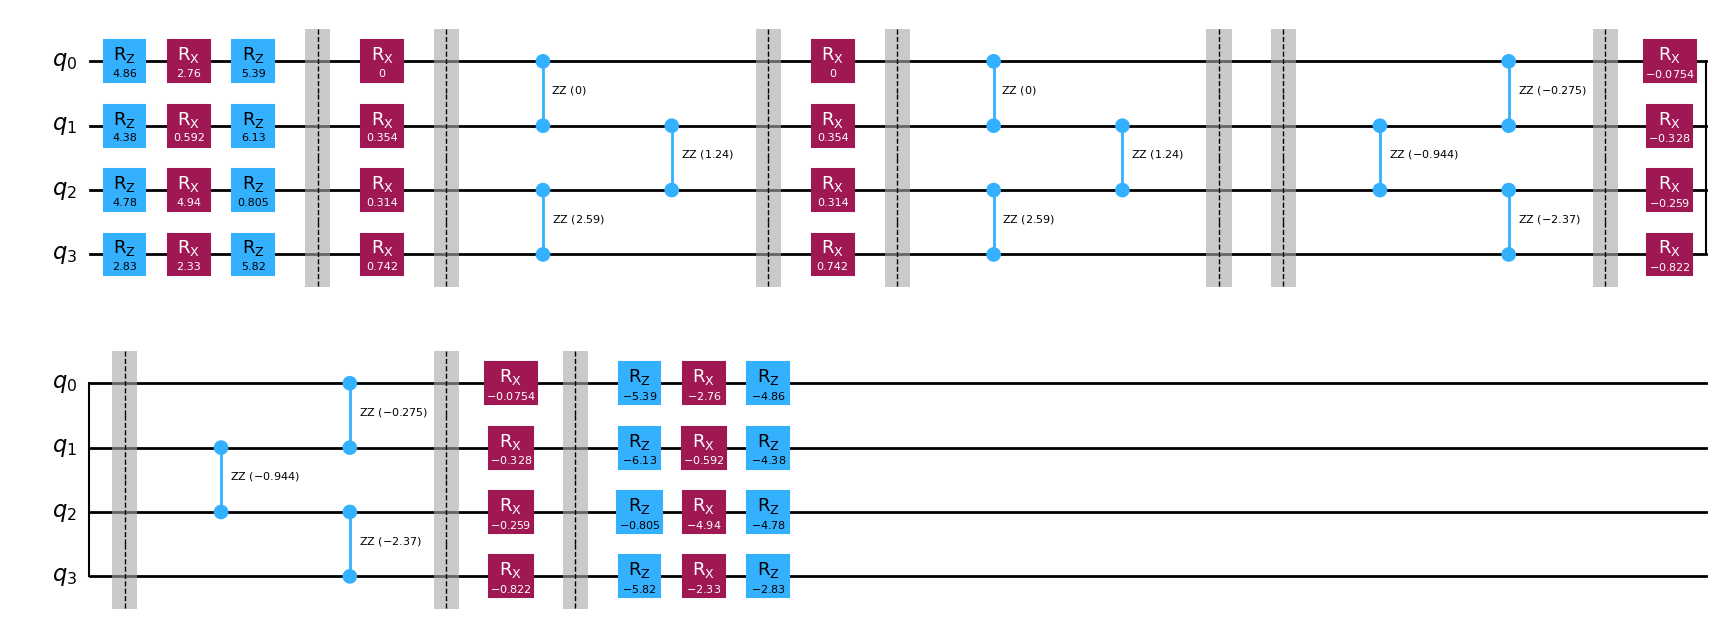

In [705]:
circ_2_9_fid.draw("mpl")

#### Empirical Time Estimation

Before running the full QESEM mitigation job, it is recommended to first run an empirical time estimation job, especially if the job includes deep circuits of a large volume. This is a lightweight preliminary experiment that provides a fairly accurate estimate of the total QPU time required for the full mitigation job to reach the target precision for all input observables.

For running an empirical time estimation, set "estimate_time_only" in the job options to "empirical":


In [ ]:
# pubs = [(circ, obs_list_ex2, circ_parameters, precision)]

# we can transpile the circ, or not, qesem has its own transpilation stage, but a good pretranspilation or layerification of the circuit can help
basis_gates = ["rzz", "rz", "rx", "x", "sx","cz"]


job_time_est_2_9_fid = qesem_function.run(
    pubs=[(qiskit.transpile(circ_2_9_fid, basis_gates=basis_gates), P0, [], precision)],
    backend_name="fake_fez",
    options={
        "estimate_time_only": "empirical",
        "max_execution_time": 600, # another thing we can set in the options is the max_execution_time, to limit the QPU time. It is specified in seconds, e.g. max_execution_time = 600 is 10 mins.
    }
)

To monitor the job status:

In [456]:
job_time_est_2_9_fid.status()

'DONE'

Once the job is complete, the empirical QPU time estimation can be extracted from the metadata:

In [471]:
result_time_est_2_9_fid = job_time_est_2_9_fid.result()

print("time estimation (seconds):", result_time_est_2_9_fid[0].metadata['time_estimation_sec'])

time estimation (seconds): 300


#### Running the full QESEM mitigation experiment (one single kernel element)

If satisfied with the estimated QPU time, we can now run the full QESEM mitigation job. To do so, we simply remove the `estimate_time_only` option:

In [472]:
max_execution_time = 600

job_full_qesem_2_9_fid = qesem_function.run(
    pubs=[(qiskit.transpile(circ_2_9_fid, basis_gates=basis_gates), P0, [], precision)],
    backend_name="fake_fez",
    options={
        "max_execution_time": max_execution_time,
    }
)

In [489]:
#monitor the job status
job_full_qesem_2_9_fid.status()

'DONE'

In [479]:
#extract the result once the job is done
result_full_qesem_job_2_9_fid = job_full_qesem_2_9_fid.result()

Let's now print the final mitigation results and compare them against the noisy and ideal values:

In [502]:
print(rf"mitigated result for K_train[{i},{j}]: {result_full_qesem_job_2_9_fid[0].data.evs.item()} $\pm$ {result_full_qesem_job_2_9_fid[0].data.stds.item()}")
print(f"Ideal result for K_train[{i},{j}]: {K_train_ideal_ising_fidelity[i,j]}")
print(f"Unmitigated result for K_train[{i},{j}]: {result_full_qesem_job_2_9_fid[0].metadata['results'][0][0][1]['unmitigated']['value']} \pm {result_full_qesem_job_2_9_fid[0].metadata['results'][0][0][1]['unmitigated']['error_bar']}")

mitigated result for K_train[2,9]: 0.8544193610678419 $\pm$ 0.019116899807212265
Ideal result for K_train[2,9]: 0.8526987104240003
Unmitigated result for K_train[2,9]: 0.7543 \pm 0.005252117367510489


#### Running multiple full QESEM mitigation experiment using the `Parametrized Circuit` feature of QESEM

As the kernel matrices all can be evaluated by measuring one single parameterized circuit, a nice feature that can be used if the `Parametrized Circuit` feature of QESEM. Let's see how it can be used here to evaluate several fidelity kernel elements in one single job:

In [737]:
i = 9
js = [4,6,8]
parameters = [np.concatenate([x_train[i], x_train[j]]) for j in js]
parameters_prod = [list(elem) for elem in np.array(parameters).transpose()]
basis_gates = ["rz", "rx", "x", "sx","cz"]
circ_fid_parameterized = qiskit.transpile(fidelity_circ(ising_trotter_feature_map(n_qubits, 2, h, J, labels=range(n_qubits)), ising_trotter_feature_map(n_qubits, 2, h, J, labels=range(n_qubits, 2*n_qubits))))

job_fid_param = qesem_function.run(
    pubs=[(circ_fid_parameterized, P0, parameters, precision)],
    backend_name="fake_fez",
    options={
        "transpilation_level": 0,
    }
)

In [755]:
result_fid_param = job_fid_param.result()


In [758]:
# extract the ideal vals
ideal_values_fid_param = {
    f"K_{{{i},{j}}}": K_train_ideal_ising_fidelity[i,j]
    for j in js
}

# extract the mitigated vals
mitigated_values_fid_param = {
    f"K_{{{i},{j}}}": (result_fid_param[0].data.evs[j_idx], result_fid_param[0].data.stds[j_idx])
    for j_idx, j in enumerate(js)
}

# extract the noisy vals
noisy_values_fid_param = {
    f"K_{{{i},{j}}}": (result_fid_param[0].metadata['noisy_results'].evs[j_idx], result_fid_param[0].metadata['noisy_results'].stds[j_idx])
    for j_idx, j in enumerate(js)
}
print("-" * 75)
print(f"{'Observable':<15} {'Ideal':>10} {'Mitigated':>20} {'Noisy':>20}")
print("-" * 75)
for elem in mitigated_values_fid_param:
    mit_val, mit_std = mitigated_values_fid_param[elem]
    noi_val, noi_std = noisy_values_fid_param[elem]
    ideal_val = ideal_values_fid_param[elem]
    print(f"{elem:<15} {ideal_val:>10.3f} {mit_val:>10.3f} ± {mit_std:<8.3f} {noi_val:>10.3f} ± {noi_std:<8.3f}")
print("-" * 75)

---------------------------------------------------------------------------
Observable           Ideal            Mitigated                Noisy
---------------------------------------------------------------------------
K_{9,4}              0.440      0.429 ± 0.014         0.385 ± 0.004   
K_{9,6}              0.781      0.794 ± 0.020         0.689 ± 0.007   
K_{9,8}              0.374      0.378 ± 0.013         0.344 ± 0.006   
---------------------------------------------------------------------------


### Evaluating the Projected Kernel with QESEM


In [540]:
i = 9
circ_projected = ising_trotter_feature_map(n_qubits, 3, h, J, labels=range(n_qubits)).assign_parameters(x_train[i])
paulis_xyz = generate_single_qubit_paulis(n_qubits)

In [541]:
job_projected_i9 = qesem_function.run(
    pubs=[(qiskit.transpile(circ_projected, basis_gates=basis_gates), paulis_xyz, [], precision)],
    backend_name="fake_fez",
    options={
        "max_execution_time": max_execution_time,
    }
)

In [542]:
job_projected_i9.status()

'QUEUED'

In [543]:
result_projected_i9 = job_projected_i9.result()

In [545]:
ideal_state = Statevector(circ_projected)
ideal_values = {p.paulis[0]: ideal_state.expectation_value(p).real for p in paulis_xyz}


mitigated_values = {
    p.paulis[0]: (result_projected_i9[0].data.evs[i], result_projected_i9[0].data.stds[i])
    for i, p in enumerate(paulis_xyz)
}

noisy_values = {
    p.paulis[0]: (result_projected_i9[0].metadata['noisy_results'].evs[i], result_projected_i9[0].metadata['noisy_results'].stds[i])
    for i, p in enumerate(paulis_xyz)
}
print("-" * 75)
print(f"{'Observable':<15} {'Ideal':>10} {'Mitigated':>20} {'Noisy':>20}")
print("-" * 75)
for pauli in mitigated_values:
    mit_val, mit_std = mitigated_values[pauli]
    noi_val, noi_std = noisy_values[pauli]
    ideal_val = ideal_values[pauli]
    print(f"{str(pauli):<15} {ideal_val:>10.3f} {mit_val:>10.3f} ± {mit_std:<8.3f} {noi_val:>10.3f} ± {noi_std:<8.3f}")
print("-" * 75)

---------------------------------------------------------------------------
Observable           Ideal            Mitigated                Noisy
---------------------------------------------------------------------------
IIIX                -0.047     -0.048 ± 0.006        -0.037 ± 0.012   
IIXI                -0.243     -0.230 ± 0.013        -0.232 ± 0.017   
IXII                 0.106      0.105 ± 0.009         0.098 ± 0.014   
XIII                -0.048     -0.047 ± 0.006        -0.053 ± 0.013   
IIIY                 0.013      0.013 ± 0.004         0.035 ± 0.012   
IIYI                 0.469      0.482 ± 0.012         0.435 ± 0.014   
IYII                 0.064      0.062 ± 0.007         0.071 ± 0.012   
YIII                 0.037      0.029 ± 0.007         0.044 ± 0.014   
IIIZ                 0.982      0.978 ± 0.021         0.934 ± 0.005   
IIZI                 0.718      0.716 ± 0.021         0.675 ± 0.009   
IZII                 0.893      0.888 ± 0.021         0.829 ± 0.006  